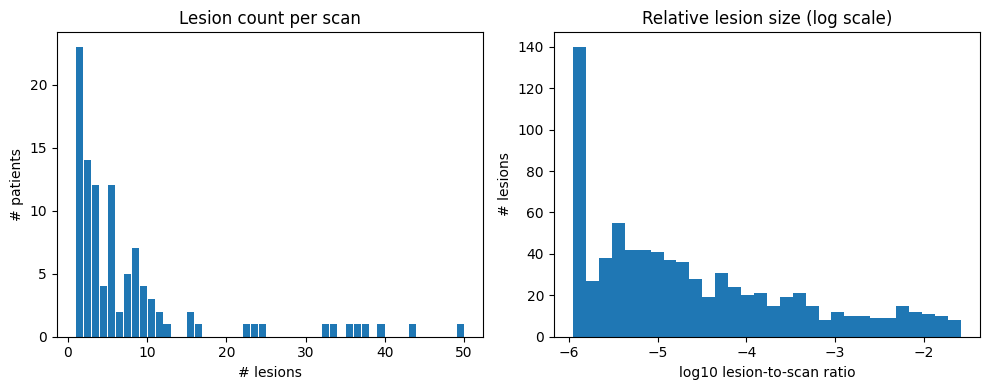

,count,mean,std,min,25%,50%,75%,max
lesion_count,103.0,7.621359,10.103500,1.000000,2.000000,4.000000,8.000000,49.000000
lesion_ratio_patient,103.0,0.007813,0.007375,0.000023,0.000841,0.006471,0.012879,0.032354



Saved: patient_summary.csv, lesion_summary.csv


In [26]:
# ───────── USER CONFIG ─────────
npy_root_dir  = "/mnt/external/data/BraTS_3D"   # folders containing *-seg.npy
nii_root_dir  = "/home/aldo_marzullo/data/BraTS/Training"   # parallel tree with *-seg.nii.gz
save_patient_csv = "patient_summary.csv"
save_lesion_csv  = "lesion_summary.csv"
# ───────────────────────────────

import os, glob
import numpy as np, pandas as pd
from scipy.ndimage import label
import matplotlib.pyplot as plt
import nibabel as nib             # always import; used only if file exists

def find_nii(seg_npy_path):
    """Construct expected .nii.gz path given a seg.npy path."""
    tail = seg_npy_path.replace(npy_root_dir, "").lstrip(os.sep)
    return os.path.join(nii_root_dir, tail).replace("-seg.npy", "-seg.nii.gz")

def analyse_case(seg_npy):
    pid   = os.path.basename(os.path.dirname(seg_npy))
    mask  = np.load(seg_npy) > 0        # binary
    nii   = find_nii(seg_npy)
    spacing = nib.load(nii).header.get_zooms() if os.path.exists(nii) else (1,1,1)
    voxvol = np.prod(spacing)

    cc, n_l = label(mask)
    les_vox = [(cc == i).sum() for i in range(1, n_l+1)]
    scan_vox = mask.size

    # per-patient row
    pat = {
        "patient_id": pid,
        "lesion_count": n_l,
        "total_lesion_vox": sum(les_vox),
        "scan_vox": scan_vox,
        "lesion_ratio_patient": sum(les_vox) / scan_vox,
    }

    # per-lesion rows
    les_rows = []
    for v in les_vox:
        les_rows.append({
            "patient_id": pid,
            "lesion_vox": v,
            "lesion_ratio_scan": v / scan_vox,   # **your key metric**
            "lesion_vol_mm3": v * voxvol,
        })
    return pat, les_rows

# ---------- iterate ----------
patient_rows, lesion_rows = [], []
for seg in glob.glob(os.path.join(npy_root_dir, "*", "*-seg.npy")):
    if seg == '/mnt/external/data/BraTS_3D/BraTS-MET-00406-000/BraTS-MET-00406-000-seg.npy':
        continue
    p, l = analyse_case(seg)
    patient_rows.append(p)
    lesion_rows.extend(l)

df_pat = pd.DataFrame(patient_rows)
df_les = pd.DataFrame(lesion_rows)
df_pat.to_csv(save_patient_csv, index=False)
df_les.to_csv(save_lesion_csv,  index=False)

# ---------- mini-viz ----------
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df_pat["lesion_count"], bins=range(1, df_pat["lesion_count"].max()+2), rwidth=.9)
ax[0].set_xlabel("# lesions"); ax[0].set_ylabel("# patients")
ax[0].set_title("Lesion count per scan")

ax[1].hist(np.log10(df_les["lesion_ratio_scan"] + 1e-6), bins=30)
ax[1].set_xlabel("log10 lesion-to-scan ratio")
ax[1].set_ylabel("# lesions")
ax[1].set_title("Relative lesion size (log scale)")

plt.tight_layout(); plt.show()

display(df_pat[["lesion_count", "lesion_ratio_patient"]].describe(percentiles=[.25,.5,.75]).T)
print(f"\nSaved: {save_patient_csv}, {save_lesion_csv}")


In [13]:
# Check file properties
import os
filepath = '/mnt/external/data/BraTS_3D/BraTS-MET-00219-000/BraTS-MET-00219-000-t2w.npy'

print(f"File exists: {os.path.exists(filepath)}")
print(f"File size: {os.path.getsize(filepath)} bytes")

# Try to read the file header
with open(filepath, 'rb') as f:
    header = f.read(16)
    print(f"File header (hex): {header.hex()}")
    print(f"File header (ascii): {header}")

File exists: True
File size: 71424128 bytes
File header (hex): 934e554d5059010076007b2764657363
File header (ascii): b"\x93NUMPY\x01\x00v\x00{'desc"


In [22]:
# Try different loading approaches
import numpy as np

filepath = '/mnt/external/data/BraTS_3D/BraTS-MET-00217-000/BraTS-MET-00217-000-t2w.npy'

# Method 1: Try with allow_pickle=False
try:
    arr = np.load(filepath, allow_pickle=False)
    print("Loaded with allow_pickle=False")
    print(f"Shape: {arr.shape}, dtype: {arr.dtype}")
except Exception as e:
    print(f"Failed with allow_pickle=False: {e}")

# Method 2: Try with mmap_mode
try:
    arr = np.load(filepath, mmap_mode='r')
    print("Loaded with mmap_mode='r'")
    print(f"Shape: {arr.shape}, dtype: {arr.dtype}")
except Exception as e:
    print(f"Failed with mmap_mode: {e}")

# Method 3: Try loading as memmap directly
try:
    arr = np.memmap(filepath, mode='r')
    print("Loaded as memmap")
    print(f"Shape: {arr.shape}, dtype: {arr.dtype}")
except Exception as e:
    print(f"Failed as memmap: {e}")

Loaded with allow_pickle=False
Shape: (240, 240, 155), dtype: float64
Loaded with mmap_mode='r'
Shape: (240, 240, 155), dtype: float64
Loaded as memmap
Shape: (71424128,), dtype: uint8


In [21]:
path_seg = '/home/aldo_marzullo/data/BraTS/Training/BraTS-MET-00217-000/BraTS-MET-00217-000-seg.nii.gz'
path_t2w = '/home/aldo_marzullo/data/BraTS/Training/BraTS-MET-00217-000/BraTS-MET-00217-000-t2w.nii.gz'

out_folder = '/mnt/external/data/BraTS_3D/BraTS-MET-00217-000'

img = nib.load(path_seg)

        # Get the image data as a NumPy array
data = img.get_fdata()

# Ensure the output directory exists before saving
out_path = os.path.join(out_folder, 'BraTS-MET-00217-000-seg.npy')
output_dir = os.path.dirname(out_folder)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True) # exist_ok=True prevents error if dir already exists

# Save the NumPy array to a .npy file
print(data.shape)
np.save(out_path, data)


(240, 240, 155)


In [ ]:
import numpy as np
a = np